In [1]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2

# Read the image using opencv
image = cv2.imread('Dhurandhar.jpg')
cv2.imshow("RGB",image)
cv2.waitKey()

# Found the shape of the image
image.shape

# Print the pixel values
print(image)

[[[165 162 147]
  [162 159 145]
  [169 166 151]
  ...
  [ 60  43  17]
  [ 62  45  19]
  [ 62  45  19]]

 [[169 166 151]
  [167 164 149]
  [161 158 143]
  ...
  [ 56  39  13]
  [ 59  42  16]
  [ 61  44  18]]

 [[166 163 148]
  [164 161 146]
  [163 160 145]
  ...
  [ 55  38  12]
  [ 56  39  13]
  [ 59  42  16]]

 ...

 [[ 88  75  49]
  [ 80  67  41]
  [ 86  73  47]
  ...
  [103  91  73]
  [ 92  76  60]
  [ 95  84  64]]

 [[ 82  69  43]
  [ 79  66  40]
  [ 77  66  39]
  ...
  [ 89  82  57]
  [ 87  81  58]
  [ 93  82  55]]

 [[ 79  66  40]
  [ 80  67  41]
  [ 80  69  42]
  ...
  [ 96  85  63]
  [ 95  86  66]
  [ 92  78  55]]]


# RGB TO COLOR

In [3]:
image = cv2.imread("Dhurandhar.jpg")
gray_scale = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
cv2.imshow("Gray",gray_scale)
cv2.waitKey()
cv2.destroyAllWindows()

# Edge Detection

In [4]:
import numpy as np 
import cv2 as cv

image_path = "Half Image.jpg"
image = cv.imread(image_path)
print(image.shape)
cv.imshow("Gray",image)
cv.waitKey()

(1632, 1632, 3)


-1

In [5]:
gray_scale = cv.imread(image_path,cv.IMREAD_GRAYSCALE)
print(gray_scale.shape)
cv.imshow("Gray",gray_scale)
cv.waitKey()

(1632, 1632)


-1

# Sobel Vertical

In [18]:
import numpy as np
# Sobel Vertical
sobel_vertical = np.array([[-1,0,1],
                           [-2,0,2],
                           [-1,0,1]])

In [19]:
gray_scale.shape

(1632, 1632)

In [20]:
rows , cols = gray_scale.shape
print(rows,cols)

1632 1632


In [21]:
k = sobel_vertical.shape[0]
print(k)

3


In [22]:
output_matrix = np.zeros((rows - k + 1,cols - k + 1))

In [11]:
for i in range(1,rows-1):
    for j in range(1,cols-1):
        region = image[i-1:i+2,j-1:j+2]
        output_matrix[i-1,j-1] = np.sum(region * sobel_vertical)

In [12]:
print(output_matrix)

[[  0.   0.   0. ... -60. -60. -60.]
 [  0.   0.   0. ... -60. -60. -60.]
 [  0.   0.   0. ... -60. -60. -60.]
 ...
 [  0.   0.   0. ... -84. -84. -84.]
 [  0.   0.   0. ... -84. -84. -84.]
 [  0.   0.   0. ... -84. -84. -84.]]


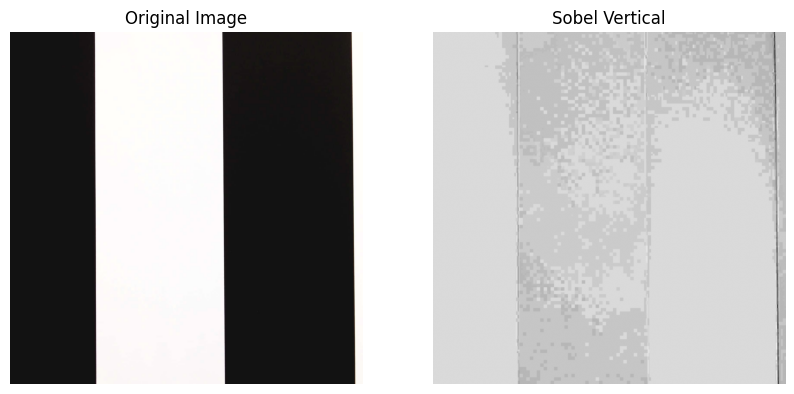

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image,cmap="gray")
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Sobel Vertical")
plt.imshow(output_matrix,cmap="gray")
plt.axis("off")

plt.show()


# Sobel Vertical 

In [23]:
# Above feature is provided in cv2 as a function 
# so no need to write it from scratch
sobel_output = cv.filter2D(image,0,sobel_vertical)
sobel_output.shape

(512, 512)

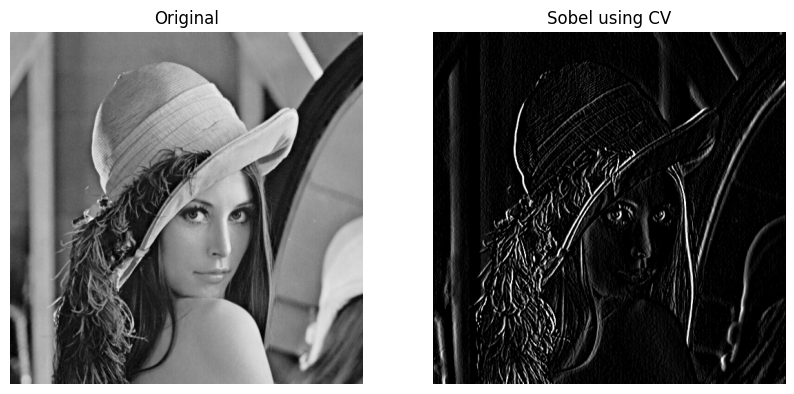

In [24]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image,cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Sobel using CV")
plt.imshow(sobel_output,cmap='gray')
plt.axis('off')
plt.show()

# Horizontal Sobel 

(np.float64(-0.5), np.float64(1631.5), np.float64(1631.5), np.float64(-0.5))

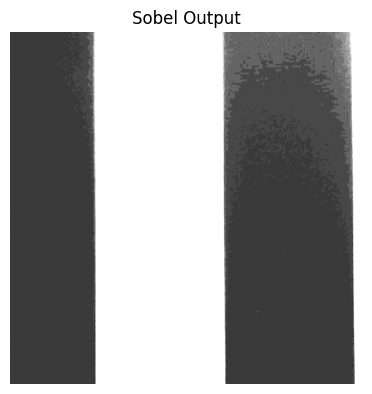

In [16]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

image_path = "Half Image.jpg"

image = cv.imread(image_path,cv.IMREAD_GRAYSCALE)

sobel_horizontal = np.array([[+1,+2,+1],
                             [0,0,0],
                             [1,2,1]])

sobel_horizontal_image = cv.filter2D(image,0,sobel_horizontal)
sobel_horizontal_image.shape

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Sobel Output")
plt.imshow(sobel_horizontal_image,cmap='gray')
plt.axis('off')

# Practice Of Filters

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

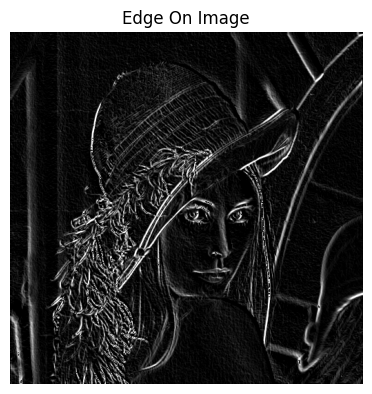

In [17]:
import cv2 as cv
import numpy as np 
import matplotlib.pyplot as plt

image_path = 'Lenna_(test_image).png'
image = cv.imread(image_path,cv.IMREAD_GRAYSCALE)

sobel_horizontal = np.array([[1,2,1],
                            [0,0,0],
                            [-1,-2,-1]])

sobel_vertical = np.array([[-1,0,1],
                           [-2,0,2],
                           [-1,0,1]])

Gx = cv.filter2D(image,-1,sobel_horizontal)
Gy = cv.filter2D(image,-1,sobel_vertical)

'''
Note:

Gx = cv.filter2D(image, -1, sobel_horizontal)
Gy = cv.filter2D(image, -1, sobel_vertical)

-1 → keeps output as uint8
Sobel produces negative values
Negative values get clipped to 0 ❌ → edges look wrong

✅ Fix (must do)
Gx = cv.filter2D(image, cv.CV_64F, sobel_horizontal)
Gy = cv.filter2D(image, cv.CV_64F, sobel_vertical)

'''

G = np.abs(Gx) + np.abs(Gy)

# Normalization 
G = (G/G.max())*255

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Edge On Image')
plt.imshow(G,cmap='gray')
# plt.imshow(G)
plt.axis('off')

